In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

In [2]:
import numpy as np 
import scipy.special
from spherical_harmonics import get_spherical_harmonic_basis_matrix, ridge_regression, construct_global_view

In [3]:
import matplotlib.pyplot as plt
import matplotlib
from mycolorpy import colorlist as mcp
font = {'family' : 'serif',
        'size'   : 14}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 

## Spherical Harmonics Regression 

In [4]:
# number of data points
N = 5
# order of spherical harmonic interpolator 
ell = 5
# ridge regression regularization 
lambda_ = 0.01

In [5]:
# latitude samples
theta_sample = np.linspace(0, np.pi, N, endpoint=False)
# longitude samples
phi_sample = np.linspace(0, 2*np.pi, N, endpoint=False)
# data at the (theta, phi) locations
data = np.random.random(N)

In [6]:
Y = get_spherical_harmonic_basis_matrix(latitude=theta_sample, longitude=phi_sample, ell=ell)

In [7]:
pred = construct_global_view(coeff=ridge_regression(basis_matrix=Y, data=data, lambda_=lambda_), 
                             longitude=phi_sample, 
                             latitude=theta_sample)

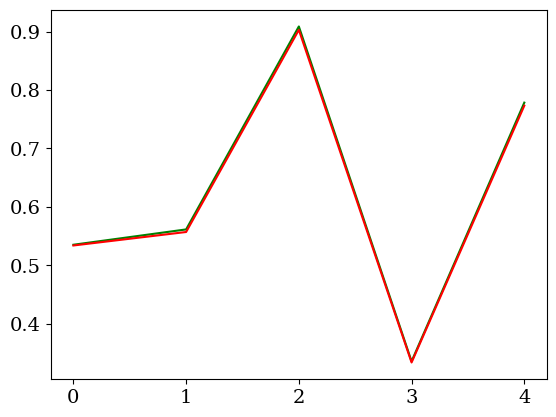

In [9]:
plt.plot(data, color="green")
plt.plot(pred, color="red")